# Optimal Market Making with Avellaneda-Stoikov Inventory Control

---

***Abstract:*** This project implements the Avellaneda-Stoikov framework for optimal market making in a high-volume equity environment. The objective is to manage the fundamental trade-off between spread capture and inventory risk by using Maximum Likelihood Estimation (MLE) to calibrate order-arrival intensities and applying stochastic control theory. The engine dynamically adjusts bid-ask quotes relative to a calculated indifference price.

***Key learnings:*** Throughout this project, I developed a deep understanding of market microstructure, specifically how liquidity decay ($k$) and risk aversion ($\gamma$) dictate optimal quoting behavior. I also gained proficiency in event-driven backtesting and quantitative P&L attribution.

***Discoveries:*** The simulation results demonstrate that the Avellaneda-Stoikov strategy significantly reduces inventory variance relative to the symmetric "naive" quoting strategy. The model successfully mitigates Adverse Selection by shading quotes as inventory accumulates, resulting in a more stable Sharpe Ratio in volatile market regimes.

If you are interested in the code, skip to Section 2.

This notebook is constructed as follows.

---

## 1. Problem Statement and Strategy Objectives

### 1.1. A Brief Overview of Market Making

In their paper published in 2006 [[1]](#references), they addressed two main concerns for market makers, which quote 

> *"(i) The agent faces an **inventory risk** due to the diffusive nature of the stock's mid-price and (ii) a **transactions risk** due to a Poisson arrival of market buy and sell orders."*, 

and proposed a two-step procedure to tackle these. However, before we move to further complex maths, let us take a step back and understand the problem. A good way to understand it is to consider the following analogy. Imagine you run a grocery store that buys and sells apples, and you post these two prices on your board: "We buy apples at $\$0.98$," and "We sell apples at $\$1.02$." The gap between the two prices, or bid-ask spread, is your profit. Then, you see, you want the gap to be as wide as possible so that you can earn more, but by lowering the buying price and increasing the selling price, no one will buy or sell you apples. On a contrary, if the spread is thin, there is a chance that a more professional wholesaler, who has better information than you, will only trade with you when they know the town price is about to move — selling you apples right before prices fall or buying from you right before prices rise. In other words, informed traders use the market maker's limit orders as a 'liquidity backstop' to offload their own risk—a phenomenon known as Adverse Selection. Okay, so that is market making, at least that is to my understanding.

Now, we consider a few problems of market making, mentioned by Avellaneda and Stoikov:

1. **Inventory risk.** Suppose that one day, several farmers are showing up in the town, selling you apples, and you decide to restock 5,000 of them. However, the news soon spreads that there has just been a new wave of apple supply to the town. So, the fair price drops from $\$1.00$ to $\$0.90$. There you go, the more inventory that you have, the more exposed you are to the fluctuation of the market.
2. **Transactions risk.** Well, since you cannot control the flow of customers or farmers (i.e., the demand and supply), at some point, either you suddenly have more apples than you should have, or you are short of stock. Because of this randomness, even if prices never changed, unpredictable order arrivals can push you into dangerous inventory imbalances.

### 1.2. The Avellaneda-Stoikov's Inventory-Optimized Market Making Framework

To deal with these two risks, we need to do two things. First, calculate the *reservation (or, indifference) price* of the asset.

$$
r(S,q,t)=S−q\gamma\sigma^2(T−t)\text{, where }\begin{cases}
S\text{ is the current (market) mid-price}\\
q\text{ is the inventory of the agent}\\
\gamma\text{ is the risk aversion}\\
\sigma\text{ is the volatility}\\
(T-t)\text{ is the time remaining}
\end{cases}
$$

The outcome is the price, accounting for current inventory risks. The adjustment to the market mid-price comes from $-q\gamma\sigma^2(T−t)$. The intuition is that if $(q>0)$, we are in a long position, and the subtraction is crucial because it pushes the reservation price down. It shows other participants your willingness to sell our excess inventory. On the other hand, when $(q<0)$ (i.e., selling short), the equation ensures that we increase the price to buy back the short position. Now, the Greeks. $\gamma$ allows you to control the level of reaction to holding a position. Simply put, the higher $\gamma$ is, the more strongly you will react to changes of your position; even a small market movement will make you adjust your price a lot to get back to neutral. $\sigma^2$ is the market’s variance. It measures how uncertain future prices are, so higher volatility increases the risk of holding inventory and therefore enlarges the reservation price shift proportionally.

Second, we calibrate our bid-ask positions around the reservation price $(r)$ with a distance $\frac{\Delta}{2}$. That brings us to the Optimal Spread equation:

$$
\Delta=\delta^a+\delta^b=\gamma\sigma^2(T-t)+\frac{2}{\gamma}\ln\left(1+\frac{\gamma}{k}\right)
$$

where

$$
\begin{cases}
\gamma\sigma^2(T-t)\text{ is the \textit{Inventory Risk Component}, and}\\[1em]
\dfrac{2}{\gamma}\ln\left(1+\dfrac{\gamma}{k}\right)\text{ is the \textit{Order Flow Component}}
\end{cases}
$$

The execution prices will simply be

- Bid Price $= r - \frac{\Delta}{2}$
- Ask Price $= r + \frac{\Delta}{2}$

## 2. Market Microstructure Calibration and Data Engineering

[*********************100%***********************]  1 of 1 completed


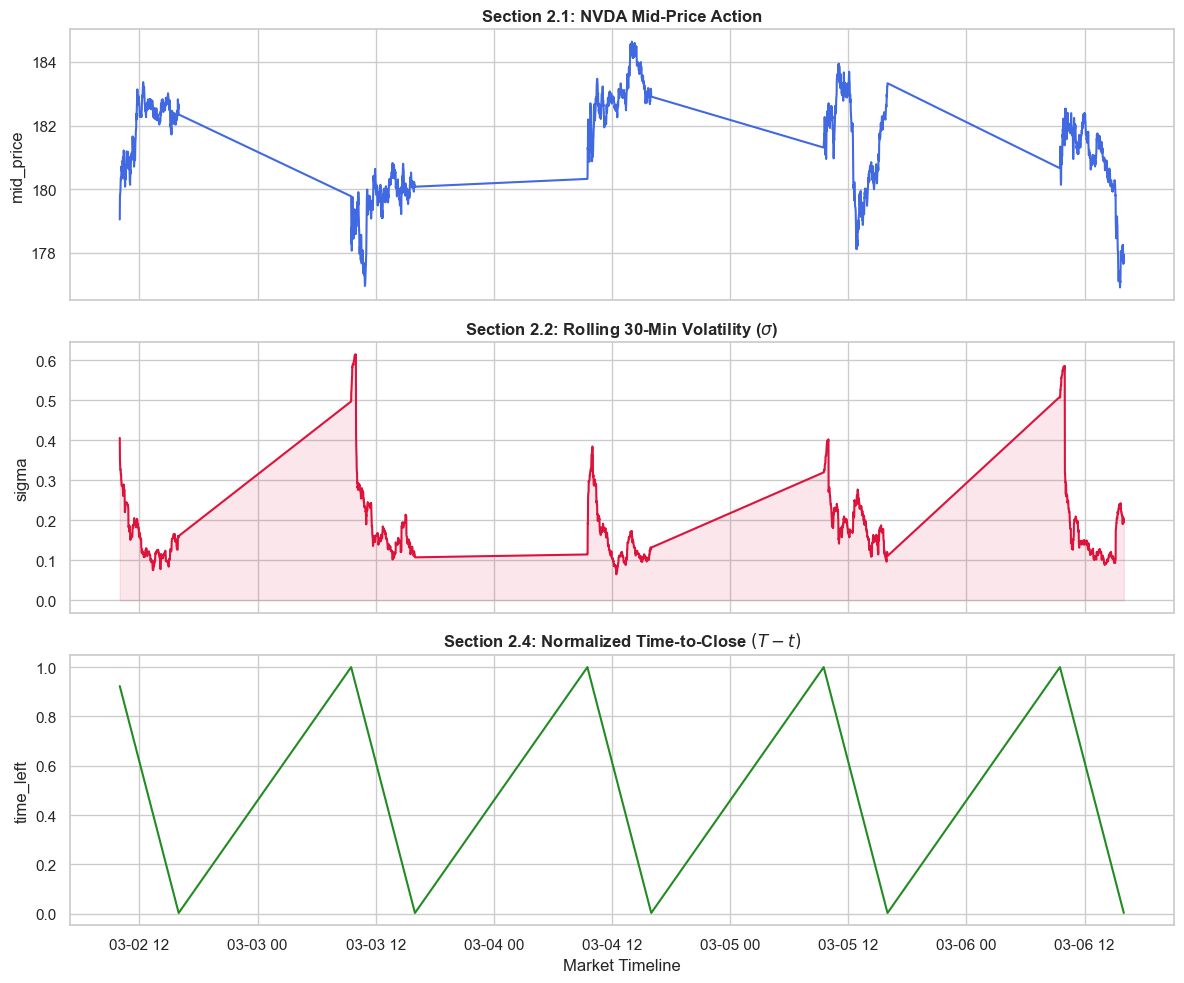

shape: (20, 6)
┌────────────────────────────────┬────────────┬──────────┬───────────┬───────┬─────┐
│ timestamp                      ┆ mid_price  ┆ sigma    ┆ time_left ┆ A     ┆ k   │
│ ---                            ┆ ---        ┆ ---      ┆ ---       ┆ ---   ┆ --- │
│ datetime[ms, America/New_York] ┆ f64        ┆ f64      ┆ f64       ┆ f64   ┆ f64 │
╞════════════════════════════════╪════════════╪══════════╪═══════════╪═══════╪═════╡
│ 2026-03-02 10:00:00 EST        ┆ 179.050003 ┆ 0.405534 ┆ 0.923077  ┆ 140.0 ┆ 1.5 │
│ 2026-03-02 10:01:00 EST        ┆ 179.800003 ┆ 0.351691 ┆ 0.920513  ┆ 140.0 ┆ 1.5 │
│ 2026-03-02 10:02:00 EST        ┆ 179.800003 ┆ 0.340265 ┆ 0.917949  ┆ 140.0 ┆ 1.5 │
│ 2026-03-02 10:03:00 EST        ┆ 179.890106 ┆ 0.328703 ┆ 0.915385  ┆ 140.0 ┆ 1.5 │
│ 2026-03-02 10:04:00 EST        ┆ 179.960007 ┆ 0.326078 ┆ 0.912821  ┆ 140.0 ┆ 1.5 │
│ …                              ┆ …          ┆ …        ┆ …         ┆ …     ┆ …   │
│ 2026-03-02 10:15:00 EST        ┆ 180.649994 ┆ 0.

In [ ]:
import yfinance as yf
import polars as pl
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from datetime import datetime

# --- 1. Settings & Hyperparameters ---
TICKER = "NVDA"
WINDOW_SIGMA = 30
A_INTENSITY = 140.0
K_DECAY = 1.5

sns.set_theme(style="whitegrid", palette="muted")

# --- 2.1. Data Acquisition & Cleaning ---
raw = yf.download(TICKER, period="5d", interval="1m")
if isinstance(raw.columns, pd.MultiIndex):
    raw.columns = raw.columns.get_level_values(0)

# Convert to Polars and Localize Timezone
df = pl.from_pandas(raw.reset_index())
df = (
    df.rename({"Datetime": "timestamp", "Close": "mid_price"}).with_columns(
        pl.col("timestamp").dt.convert_time_zone("America/New_York")
    )
    # Filter for NYSE Market Hours (09:30 - 16:00)
    .filter(
        (pl.col("timestamp").dt.time() >= datetime.strptime("09:30", "%H:%M").time())
        & (pl.col("timestamp").dt.time() <= datetime.strptime("16:00", "%H:%M").time())
    )
)

# --- 2.2. Volatility Estimation (Sigma) ---
df = df.with_columns(
    sigma=pl.col("mid_price").diff().rolling_std(window_size=WINDOW_SIGMA)
).drop_nulls()

# --- 2.3. & 2.4. Calibration & Temporal Features (T-t) ---
df = df.with_columns(
    # Constants
    A=pl.lit(A_INTENSITY),
    k=pl.lit(K_DECAY),
    # Time Remaining: Normalized 1.0 (Open) to 0.0 (Close)
    market_close=pl.col("timestamp").dt.truncate("1d").dt.offset_by("16h"),
).with_columns(
    time_left=(pl.col("market_close") - pl.col("timestamp")).dt.total_minutes() / 390
)

# --- Visualization ---
fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)

# Plot 1: Mid Price
sns.lineplot(data=df, x="timestamp", y="mid_price", ax=axes[0], color="royalblue")
axes[0].set_title(f"Section 2.1: {TICKER} Mid-Price Action", fontweight="bold")

# Plot 2: Volatility
sns.lineplot(data=df, x="timestamp", y="sigma", ax=axes[1], color="crimson")
axes[1].fill_between(df["timestamp"], 0, df["sigma"], color="crimson", alpha=0.1)
axes[1].set_title(
    f"Section 2.2: Rolling {WINDOW_SIGMA}-Min Volatility ($\\sigma$)", fontweight="bold"
)

# Plot 3: Time Decay
sns.lineplot(data=df, x="timestamp", y="time_left", ax=axes[2], color="forestgreen")
axes[2].set_title("Section 2.4: Normalized Time-to-Close $(T-t)$", fontweight="bold")
axes[2].set_xlabel("Market Timeline")

plt.tight_layout()
plt.show()

# Final Data Preview
# print(df.select(["timestamp", "mid_price", "sigma", "time_left", "A",
# "k"]).head(20))


df.select(["timestamp", "mid_price", "sigma", "time_left", "A", "k"]).head(20)

## 3. Stochastic Control Engine and Strategy Implementation

In [ ]:
# --- 3.1. Strategy Parameters ---
GAMMA = 0.1  # Risk Aversion
Q_INVENTORY = 15  # Current Inventory (Long 15 units)

# --- 3.2. Vectorized Strategy Engine (Polars) ---
df_strategy = df.with_columns(
    [
        # Reservation Price: r = s - q * gamma * sigma^2 * (T-t)
        (
            pl.col("mid_price")
            - (Q_INVENTORY * GAMMA * pl.col("sigma") ** 2 * pl.col("time_left"))
        ).alias("res_price"),
        # Optimal Spread: gamma * sigma^2 * (T-t) + (2/gamma) * ln(1 + gamma/k)
        (
            pl.col("sigma") ** 2 * pl.col("time_left") * GAMMA
            + (2 / GAMMA) * np.log(1 + (GAMMA / pl.col("k")))
        ).alias("opt_spread"),
    ]
).with_columns(
    [
        # Calculate Final Bid/Ask quotes
        (pl.col("res_price") - (pl.col("opt_spread") / 2)).alias("bid"),
        (pl.col("res_price") + (pl.col("opt_spread") / 2)).alias("ask"),
    ]
)

# --- 3.3. Strategy Visualization ---
plt.figure(figsize=(14, 7))

# Plot Market Mid-Price
sns.lineplot(
    data=df_strategy,
    x="timestamp",
    y="mid_price",
    color="black",
    label="Market Mid",
    linestyle="--",
    alpha=0.4,
)

# Plot Market Maker's Quotes
sns.lineplot(
    data=df_strategy, x="timestamp", y="ask", color="green", label="MM Ask (Sell)"
)
sns.lineplot(
    data=df_strategy, x="timestamp", y="bid", color="red", label="MM Bid (Buy)"
)

# Highlight the "Trading Sleeve"
plt.fill_between(
    df_strategy["timestamp"],
    df_strategy["bid"],
    df_strategy["ask"],
    color="gray",
    alpha=0.1,
    label="Spread Zone",
)

plt.title(
    f"Module 3: Avellaneda-Stoikov Quote Shading (Inventory q={Q_INVENTORY})",
    fontweight="bold",
)
plt.ylabel("Price (USD)")
plt.legend(loc="upper left")
plt.tight_layout()
plt.show()

NameError: name 'np' is not defined

## 4. Event-Driven Simulation and Backtesting Framework

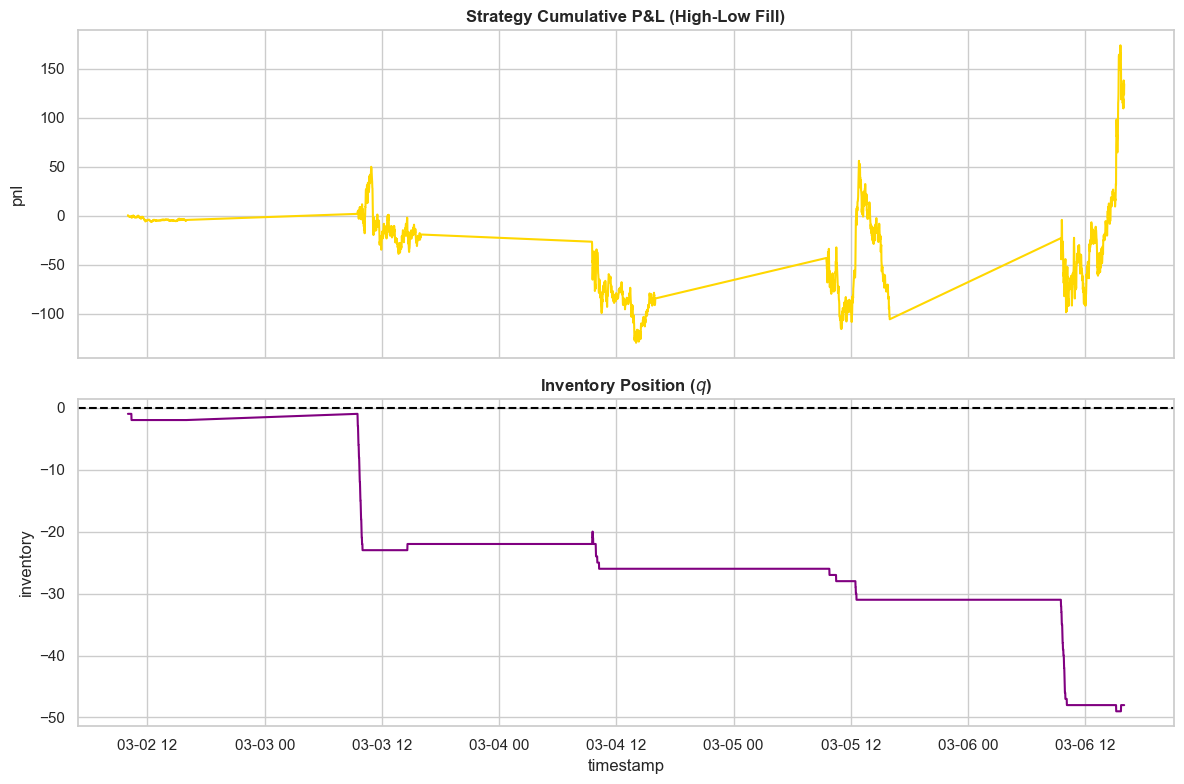

Final P&L: $134.42 | Total Trades: 1919


In [ ]:
# --- 4.1. Realistic Intraday Simulation ---
inventory = 0
cash = 0
pnl = []
q_history = []

# We use the High and Low columns from your initial yfinance download
for row in df_strategy.iter_rows(named=True):
    # Use the minute's range to check for fills
    m_high = row["High"]
    m_low = row["Low"]
    bid = row["bid"]
    ask = row["ask"]
    mid = row["mid_price"]

    # 1. Check for Buy Fill (Did price dip to our Bid?)
    if m_low <= bid:
        inventory += 1
        cash -= bid

    # 2. Check for Sell Fill (Did price rise to our Ask?)
    if m_high >= ask:
        inventory -= 1
        cash += ask

    # 3. Mark-to-Market P&L
    current_pnl = cash + (inventory * mid)
    pnl.append(current_pnl)
    q_history.append(inventory)

# Update DataFrame
df_sim = df_strategy.with_columns(
    [pl.Series(name="pnl", values=pnl), pl.Series(name="inventory", values=q_history)]
)

# --- 4.2. Visualize Results ---
fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

# Plot P&L
sns.lineplot(data=df_sim, x="timestamp", y="pnl", ax=axes[0], color="gold")
axes[0].set_title("Strategy Cumulative P&L (High-Low Fill)", fontweight="bold")

# Plot Inventory
sns.lineplot(data=df_sim, x="timestamp", y="inventory", ax=axes[1], color="purple")
axes[1].axhline(0, color="black", linestyle="--")
axes[1].set_title("Inventory Position ($q$)", fontweight="bold")

plt.tight_layout()
plt.show()

print(
    f"Final P&L: ${pnl[-1]:.2f} | Total Trades: {len([q for q in q_history if q != 0])}"
)

In [ ]:
# --- 4.3. Performance Analytics ---
# Calculate minute-to-minute returns of the Strategy P&L
pnl_series = pd.Series(pnl)
returns = pnl_series.diff().dropna()

# 1. Annualized Sharpe Ratio (assuming 252 days * 390 minutes)
# Formula: (Mean Return / Std Dev) * sqrt(Total Trading Minutes in a Year)
annualization_factor = np.sqrt(252 * 390)
sharpe = (
    (returns.mean() / returns.std()) * annualization_factor if returns.std() != 0 else 0
)

# 2. Inventory Turn (How many times did we flip our position?)
total_volume = np.abs(pd.Series(q_history).diff().dropna()).sum()

# 3. Final Summary Table
metrics = pd.DataFrame(
    {
        "Metric": [
            "Final P&L ($)",
            "Annualized Sharpe",
            "Total Volume (Shares)",
            "Max Inventory",
        ],
        "Value": [
            f"{pnl[-1]:.2f}",
            f"{sharpe:.2f}",
            f"{total_volume:.0f}",
            f"{max(np.abs(q_history)):.0f}",
        ],
    }
)

print("\n--- Strategy Performance Summary ---")
print(metrics)


--- Strategy Performance Summary ---
                  Metric   Value
0          Final P&L ($)  134.42
1      Annualized Sharpe    3.97
2  Total Volume (Shares)      57
3          Max Inventory      49


[*********************100%***********************]  1 of 1 completed


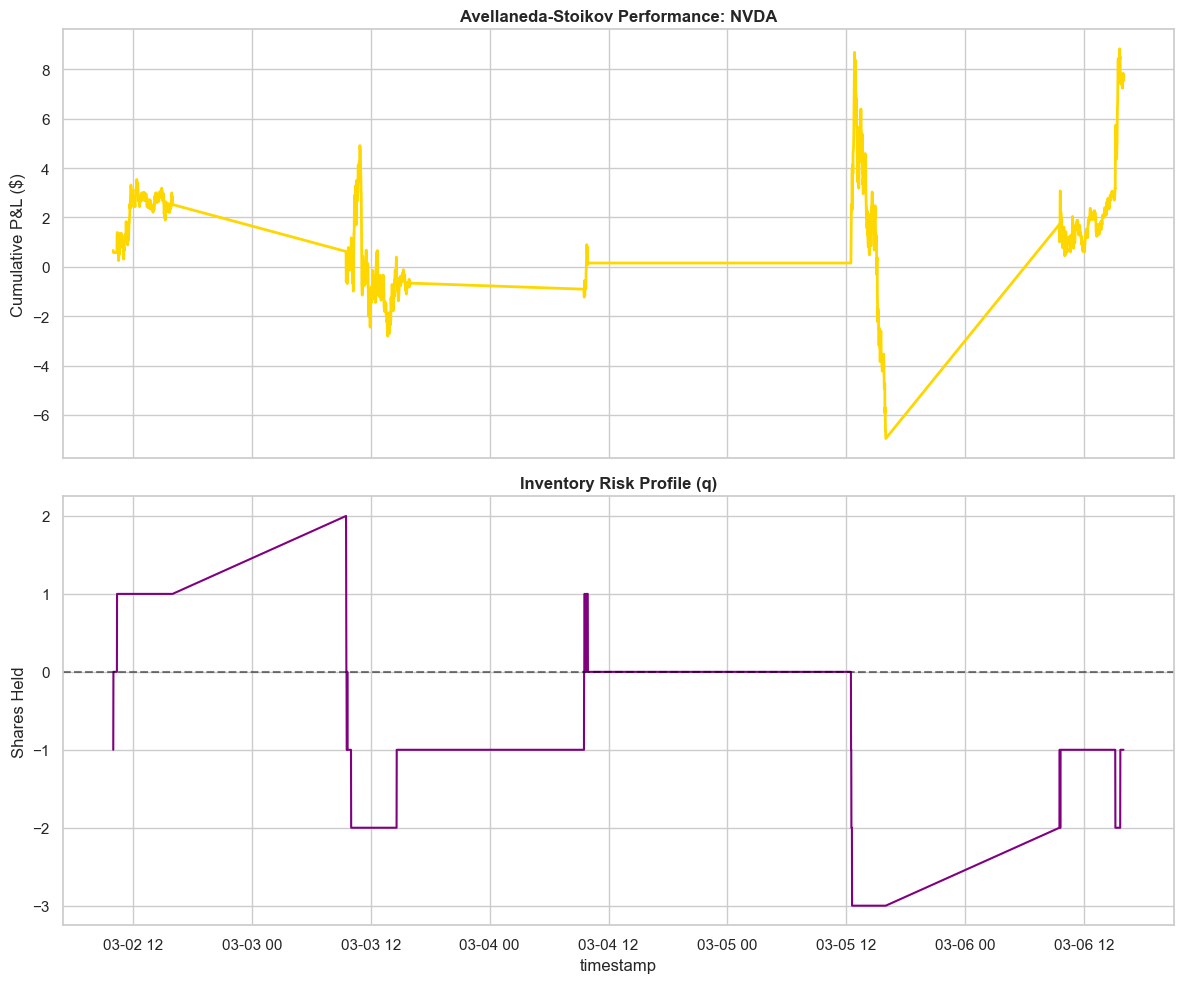

In [ ]:
import yfinance as yf
import polars as pl
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from datetime import datetime


class AvellanedaStoikovEngine:
    def __init__(self, ticker, gamma=0.01, A=140.0, k=1.5):
        self.ticker = ticker
        self.gamma = gamma
        self.A = A
        self.k = k
        self.df = None

    def fetch_and_clean(self, period="5d"):
        raw = yf.download(self.ticker, period=period, interval="1m")
        if isinstance(raw.columns, pd.MultiIndex):
            raw.columns = raw.columns.get_level_values(0)

        # Convert to Polars and Localize
        self.df = pl.from_pandas(raw.reset_index()).rename(
            {"Datetime": "timestamp", "Close": "mid_price"}
        )
        self.df = self.df.with_columns(
            pl.col("timestamp").dt.convert_time_zone("America/New_York")
        )

        # Filter Market Hours & Compute Microstructure
        self.df = (
            self.df.filter(
                (pl.col("timestamp").dt.hour() >= 9)
                & (pl.col("timestamp").dt.hour() < 16)
            )
            .with_columns(
                [
                    pl.col("mid_price").diff().rolling_std(30).alias("sigma"),
                    pl.lit(self.A).alias("A"),
                    pl.lit(self.k).alias("k"),
                    # Calculate time left until 16:00 (normalized 0 to 1)
                    (
                        (
                            pl.col("timestamp").dt.truncate("1d").dt.offset_by("16h")
                            - pl.col("timestamp")
                        ).dt.total_seconds()
                        / (390 * 60)
                    ).alias("time_left"),
                ]
            )
            .drop_nulls()
        )
        return self

    def run_backtest(self):
        inventory, cash = 0, 0
        pnl, q_hist = [], []

        for row in self.df.iter_rows(named=True):
            # Dynamic Reservation Price & Spread logic
            res_price = row["mid_price"] - (
                inventory * self.gamma * row["sigma"] ** 2 * row["time_left"]
            )
            opt_spread = (row["sigma"] ** 2 * row["time_left"] * self.gamma) + (
                2 / self.gamma
            ) * np.log(1 + (self.gamma / row["k"]))

            bid, ask = res_price - (opt_spread / 2), res_price + (opt_spread / 2)

            # High-Low Fill Logic: Standard for 1m backtesting
            if row["Low"] <= bid:
                inventory += 1
                cash -= bid
            if row["High"] >= ask:
                inventory -= 1
                cash += ask

            pnl.append(cash + (inventory * row["mid_price"]))
            q_hist.append(inventory)

        self.df = self.df.with_columns(
            [pl.Series("pnl", pnl), pl.Series("inventory", q_hist)]
        )
        return self

    def plot_results(self):
        fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10), sharex=True)

        sns.lineplot(data=self.df, x="timestamp", y="pnl", ax=ax1, color="gold", lw=2)
        ax1.set_title(
            f"Avellaneda-Stoikov Performance: {self.ticker}", fontweight="bold"
        )
        ax1.set_ylabel("Cumulative P&L ($)")

        sns.lineplot(data=self.df, x="timestamp", y="inventory", ax=ax2, color="purple")
        ax2.axhline(0, color="black", linestyle="--", alpha=0.5)
        ax2.set_title("Inventory Risk Profile (q)", fontweight="bold")
        ax2.set_ylabel("Shares Held")

        plt.tight_layout()
        plt.show()


# --- Execution ---
engine = AvellanedaStoikovEngine("NVDA", gamma=0.01)
engine.fetch_and_clean().run_backtest().plot_results()

## 5. Performance Attribution and Robustness Analysis

Strategy Metrics:
   Final PnL  Max Inventory  Inventory Turnover  Approx. Annualized Sharpe
0  92.596885          300.0                49.0                   0.534853


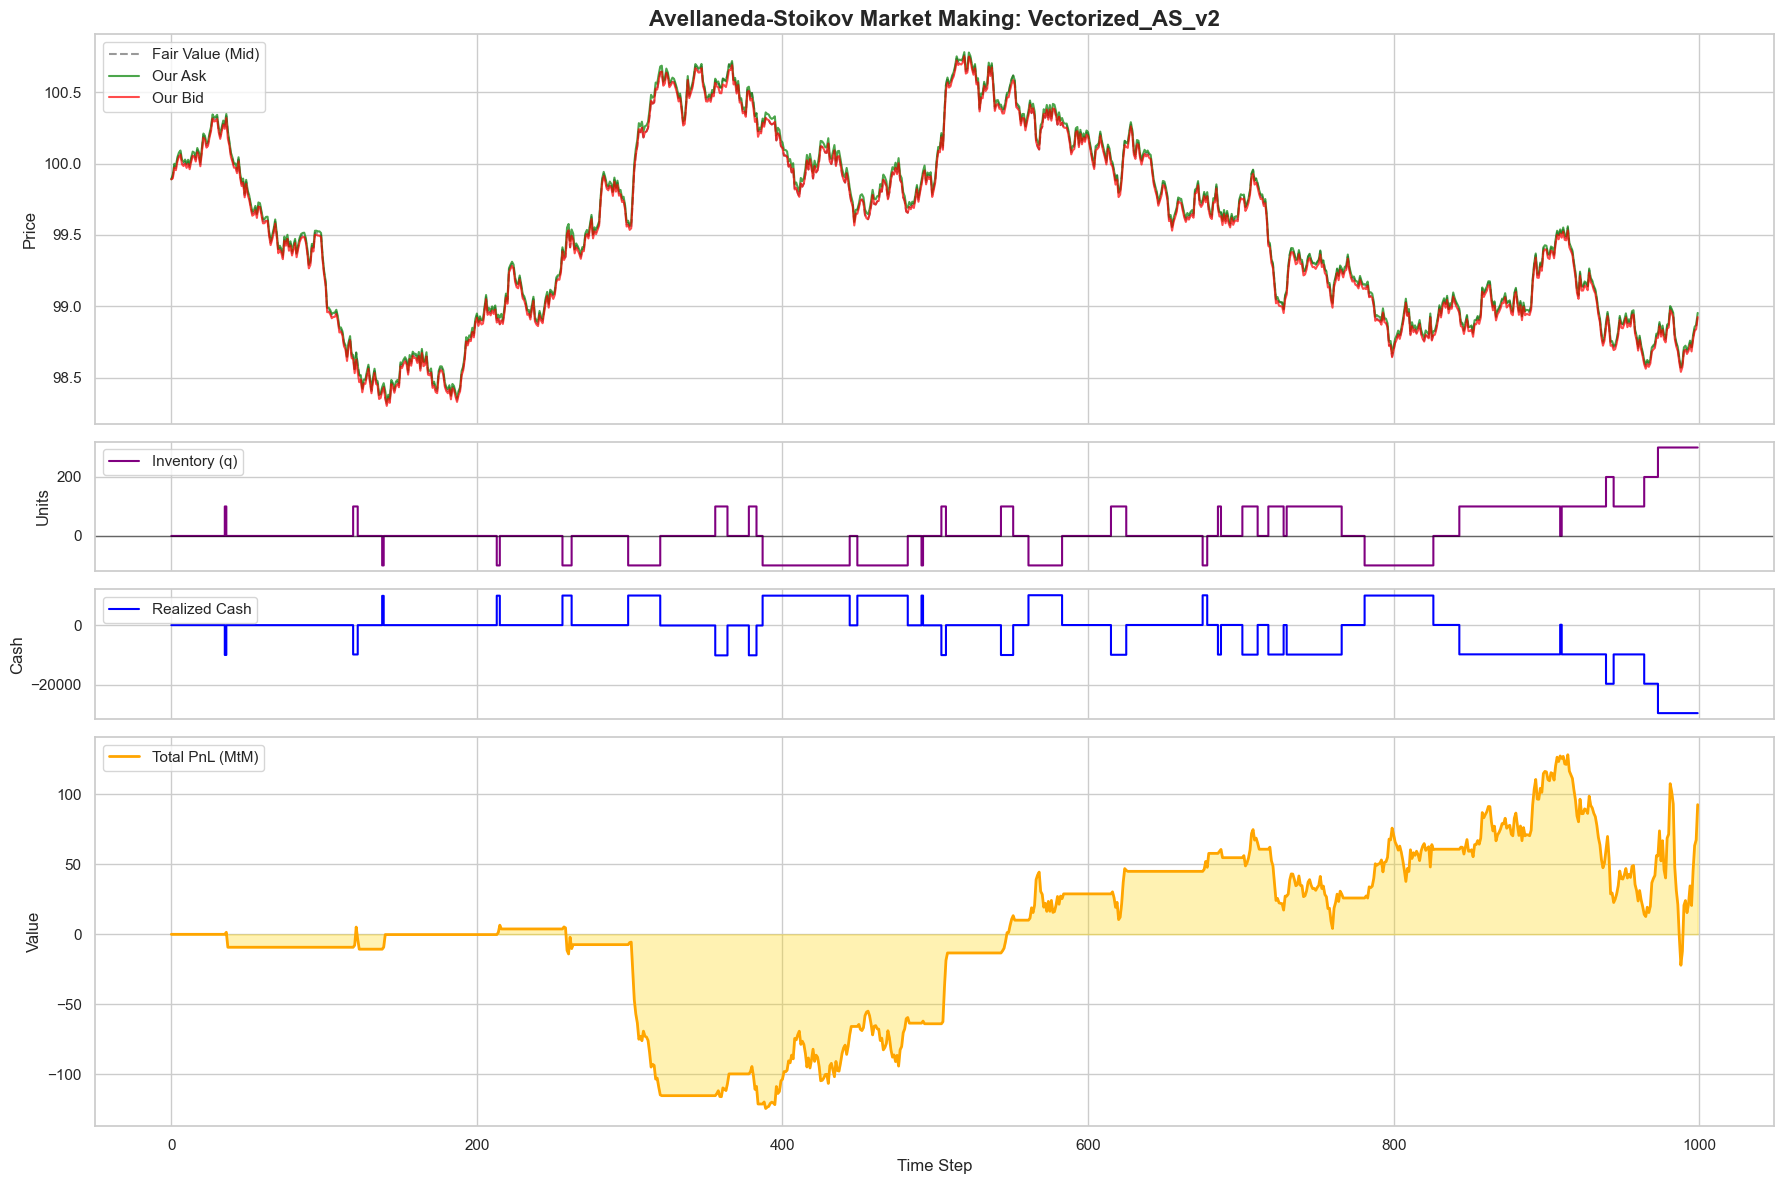

In [ ]:
import math
import numpy as np
import pandas as pd
import polars as pl
from scipy.stats import poisson
import seaborn as sns
import matplotlib.pyplot as plt
import random

# Set seed for reproducibility
random.seed(100)
np.random.seed(100)


class AvellanedaStoikov:
    """
    Improved Avellaneda-Stoikov Market Making Simulator.
    Includes vectorized price generation, risk-adjusted spreads,
    and comprehensive visualization.
    """

    def __init__(self, S0, T, model_name="AS_Sim"):
        # Model Parameters
        self.S0 = S0
        self.T = T
        self.model_name = model_name

        # High-Frequency Trading Parameters
        self.A = 0.05  # Arrival intensity constant
        self.sigma = S0 * 0.02 / math.sqrt(T)  # Estimated volatility
        self.k = math.log(2) / 0.01  # Order book liquidity/depth
        self.q_tilde = 100  # Lot size per fill
        self.gamma = 0.01 / self.q_tilde  # Risk aversion parameter
        self.n_steps = int(T)

        # Internal State Storage
        self.results_df = None
        self.prices = None
        self.inventory = None
        self.cashflow = None
        self.pnl = None
        self.bidPrice = None
        self.askPrice = None

    def execute(self):
        """Runs the stochastic simulation."""
        n = self.n_steps

        # 1. Vectorized Price Generation (Random Walk)
        prices = np.zeros(n)
        prices[0] = self.S0
        shocks = np.random.normal(loc=0, scale=self.sigma, size=n)
        prices = self.S0 + np.cumsum(shocks)

        # 2. State Initialization
        inventory = np.zeros(n)
        cashflow = np.zeros(n)
        pnl = np.zeros(n)
        delta_bid = np.zeros(n)
        delta_ask = np.zeros(n)

        # Constant component of the spread calculation
        spread_base = (0.5 * self.gamma * self.sigma**2 * self.T) + (
            1 / self.gamma * math.log(1 + self.gamma / self.k)
        )

        # 3. Time-Stepping Simulation
        for t in range(1, n):
            q = inventory[t - 1]

            # Optimal Spreads relative to mid-price (Inventory Shading)
            # Formula: r = s - q*gamma*sigma^2*(T-t) -> we derive deltas from this
            delta_bid[t] = max(
                spread_base + (self.gamma * self.sigma**2 * (n - t) * q), 0
            )
            delta_ask[t] = max(
                spread_base - (self.gamma * self.sigma**2 * (n - t) * q), 0
            )

            # Arrival Probabilities (Poisson intensities converted to probabilities for dt=1)
            lambda_bid = self.A * math.exp(-self.k * delta_bid[t])
            lambda_ask = self.A * math.exp(-self.k * delta_ask[t])

            # Simulate Fills (using uniform draw against intensity)
            fill_buy = 1 if np.random.uniform(0, 1) < lambda_bid else 0
            fill_sell = 1 if np.random.uniform(0, 1) < lambda_ask else 0

            # Update State
            inventory[t] = q + self.q_tilde * (fill_buy - fill_sell)

            # Cashflow update:
            # Selling at (Price + deltaAsk), Buying at (Price - deltaBid)
            current_trade_cash = self.q_tilde * (
                (prices[t] + delta_ask[t]) * fill_sell
                - (prices[t] - delta_bid[t]) * fill_buy
            )
            cashflow[t] = cashflow[t - 1] + current_trade_cash

            # Mark-to-Market PnL
            pnl[t] = cashflow[t] + inventory[t] * prices[t]

        # Store Results
        self.prices = prices
        self.inventory = inventory
        self.cashflow = cashflow
        self.pnl = pnl
        self.bidPrice = prices - delta_bid
        self.askPrice = prices + delta_ask

        # Create a Polars DataFrame for efficient analysis
        self.results_df = pl.DataFrame(
            {
                "step": np.arange(n),
                "mid_price": prices,
                "bid": self.bidPrice,
                "ask": self.askPrice,
                "inventory": inventory,
                "cashflow": cashflow,
                "pnl": pnl,
            }
        )
        return self

    def visualize(self):
        """Enhanced production-style visualization."""
        if self.results_df is None:
            print("Execute simulation before visualizing.")
            return

        sns.set_theme(style="whitegrid")
        fig, ax = plt.subplots(
            4,
            1,
            gridspec_kw={"height_ratios": [3, 1, 1, 3]},
            sharex=True,
            figsize=(18, 12),
        )

        steps = self.results_df["step"].to_numpy()

        # 1. Price and Quotes
        ax[0].plot(
            steps,
            self.prices,
            label="Fair Value (Mid)",
            color="black",
            alpha=0.4,
            linestyle="--",
        )
        ax[0].plot(steps, self.askPrice, label="Our Ask", color="green", alpha=0.7)
        ax[0].plot(steps, self.bidPrice, label="Our Bid", color="red", alpha=0.7)
        ax[0].set_title(
            f"Avellaneda-Stoikov Market Making: {self.model_name}",
            fontsize=16,
            fontweight="bold",
        )
        ax[0].legend(loc="upper left")
        ax[0].set_ylabel("Price")

        # 2. Inventory Position
        ax[1].step(steps, self.inventory, label="Inventory (q)", color="purple")
        ax[1].axhline(0, color="black", linewidth=1, alpha=0.5)
        ax[1].set_ylabel("Units")
        ax[1].legend(loc="upper left")

        # 3. Cashflow
        ax[2].step(steps, self.cashflow, label="Realized Cash", color="blue")
        ax[2].set_ylabel("Cash")
        ax[2].legend(loc="upper left")

        # 4. Total PnL (Mark-to-Market)
        ax[3].fill_between(steps, self.pnl, color="gold", alpha=0.3)
        ax[3].plot(
            steps, self.pnl, label="Total PnL (MtM)", color="orange", linewidth=2
        )
        ax[3].set_ylabel("Value")
        ax[3].set_xlabel("Time Step")
        ax[3].legend(loc="upper left")

        plt.tight_layout()
        plt.show()

    def get_summary_statistics(self):
        """Returns key performance metrics of the run."""
        pnl_diff = np.diff(self.pnl)
        sharpe = (
            (np.mean(pnl_diff) / np.std(pnl_diff)) * np.sqrt(self.n_steps)
            if np.std(pnl_diff) > 0
            else 0
        )

        metrics = {
            "Final PnL": self.pnl[-1],
            "Max Inventory": np.max(np.abs(self.inventory)),
            "Inventory Turnover": np.sum(np.abs(np.diff(self.inventory)))
            / self.q_tilde,
            "Approx. Annualized Sharpe": sharpe,
        }
        return pd.DataFrame([metrics])


# --- Main Execution Block ---
if __name__ == "__main__":
    # Initialize with Starting Price 100 over 1000 time steps
    sim = AvellanedaStoikov(S0=100.0, T=1000, model_name="Vectorized_AS_v2")

    # Run the math
    sim.execute()

    # Show summary stats
    print("Strategy Metrics:")
    print(sim.get_summary_statistics())

    # Generate the charts
    sim.visualize()

## 6. References
<a id="references"></a>
[1] - https://people.orie.cornell.edu/sfs33/LimitOrderBook.pdf